In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)




In [ ]:
# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 2  # Gpc
qS = 0.5
phiS = 1.0
qK =  2.67 #ori : 1.0
phiK = phiS + np.pi/3
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5


params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [4]:
print("Generating waveform...")
h = waveform_gen(*params, T=T, dt=dt)

Generating waveform...


In [5]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)
gwf.rhostat(h)

array(32.54153962)

In [6]:
h_real = h.real
h_real

array([-1.19444410e-22, -1.01633328e-22, -8.30424520e-23, ...,
       -1.96723357e-22, -2.13534893e-22, -2.21774037e-22])

In [7]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [8]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [9]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


11.606899362022393

In [10]:
p_arr, e_arr

(array([11.7       , 11.69999959, 11.69999917, ...,  5.62159697,
         5.62159237,  5.62158778]),
 array([0.4       , 0.39999998, 0.39999996, ..., 0.12687824, 0.12687808,
        0.12687792]))

In [11]:
len(p_arr)

6311629

In [12]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.01971368776220821, 0.019108341687235263, 0.015451845941009939],
 [0.019713689337112185, 0.019108343183883658, 0.01545184703159573],
 [0.019713690912014286, 0.019108344680520625, 0.015451848122172113],
 [0.019713692486921473, 0.019108346177170728, 0.015451849212759373],
 [0.019713694061824667, 0.01910834767382069, 0.015451850303346351],
 [0.019713695636715104, 0.01910834917045682, 0.01545185139392199],
 [0.01971369721163589, 0.019108350667113083, 0.015451852484513974],
 [0.019713698786543627, 0.019108352163756902, 0.015451853575095858],
 [0.019713700361440087, 0.01910835366039379, 0.01545185466567214],
 [0.01971370193633806, 0.019108355157038372, 0.015451855756254467],
 [0.01971370351124129, 0.019108356653691774, 0.015451856846843819],
 [0.019713705086149946, 0.019108358150337634, 0.015451857937427298],
 [0.01971370666105235, 0.01910835964698086, 0.015451859028008398],
 [0.01971370823597391, 0.01910836114363829, 0.015451860118600969],
 [0.019713709810886857, 0.019108362640287625, 0.

In [13]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [14]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-1,6)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [15]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1,6)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-1,6)
]

mode_freqs_l2 = []
for l, m, n in modes_l2:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l2.append(f_mode)

mode_freqs_l3 = []
for l, m, n in modes_l3:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l3.append(f_mode)

In [16]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

In [18]:
fs = 1.0/dt
nperseg = 2**16  
noverlap = nperseg * 3 // 4  # 

# nperseg = 2**14
# noverlap = nperseg // 2
f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')



/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2859815/809106386.py:7: UserWarning: Input data is complex, switching to return_onesided=False
  f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2859815/809106386.py:8: UserWarning: Input data is complex, switching to return_onesided=False
  f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')


In [19]:
Zxx_l2

array([[ 3.82648879e-26+3.01249922e-26j,  1.91369596e-26+1.50384601e-26j,
        -2.13598869e-32+1.08404522e-31j, ...,
        -2.59618028e-27-1.17450341e-26j, -7.81134120e-27-3.52492214e-26j,
        -5.48161951e-27-2.46932629e-26j],
       [-3.82166410e-26-3.01159984e-26j,  1.50338958e-26-1.91129652e-26j,
        -1.96687579e-32+1.06113951e-31j, ...,
         1.00511033e-26-6.59846507e-27j,  1.98217018e-26+3.01584086e-26j,
        -2.11236043e-26+1.38946478e-26j],
       [ 3.81684808e-26+3.01067351e-26j, -1.90888357e-26-1.50292665e-26j,
        -1.80588243e-32+1.03943701e-31j, ...,
         9.73600925e-27+7.04650310e-27j, -2.92344136e-26-2.11349345e-26j,
         2.04867768e-26+1.47994250e-26j],
       ...,
       [-3.84084129e-26-3.01517650e-26j,  1.50520364e-26-1.92086612e-26j,
        -2.69787848e-32+1.16054073e-31j, ...,
         7.74226169e-27+9.22545457e-27j, -2.76783240e-26+2.32536081e-26j,
        -1.62983986e-26-1.93851821e-26j],
       [ 3.83607738e-26+3.01428704e-26j, -1.

In [23]:
f, t, Zxx = signal.stft(h_real.get(), fs=fs, 
                               nperseg=nperseg, noverlap=noverlap, 
                               return_onesided=False)



In [24]:
t_years = t / YRSID_SI
T_total = len(h_real) * dt / YRSID_SI
t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2859815/46899857.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2859815/46899857.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=

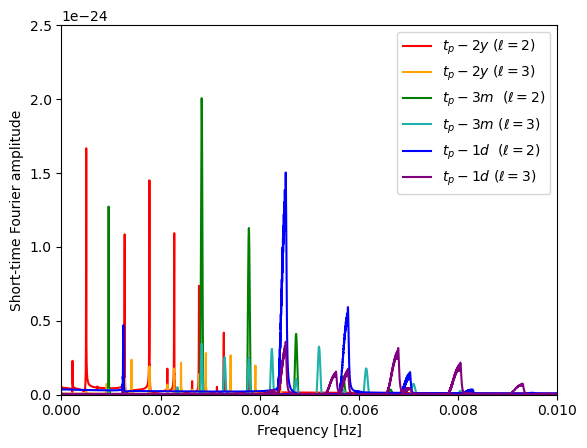

In [25]:
times_before_plunge = [2.0, 3/12, 1/365.25]  # 2y, 3m, 1d
colors_l2 = ['red', 'green', 'blue']
colors_l3 = ['orange', 'lightseagreen', 'purple']
labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
labels_l3 = ['$t_p - 2y$ ($\ell=3$)', '$t_p - 3m$ ($\ell=3$)', '$t_p - 1d$ ($\ell=3$)']

fig, ax = plt.subplots()

for time_bp, color_l2, color_l3, label_l2, label_l3 in zip(times_before_plunge, colors_l2, colors_l3, labels_l2, labels_l3):
    target_time = -time_bp
    idx = np.argmin(np.abs(t_years_adjusted - target_time))
    # amplitude = np.sqrt(Sxx[:, idx])
    amplitude_l2 = np.abs(Zxx_l2[:, idx]) 
    amplitude_l3 = np.abs(Zxx_l3[:, idx])  

    ax.plot(f_l2, amplitude_l2, color=color_l2, label=label_l2, linewidth=1.5)
    ax.plot(f_l3, amplitude_l3, color=color_l3, label=label_l3, linewidth=1.5)


ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Short-time Fourier amplitude')
ax.set_xlim([0, 0.01])
ax.set_ylim([0, 2.5*10**(-24)]) 
ax.legend()

In [ ]:
T,dt

(2.0, 10.0)

In [ ]:
snr_full = gwf.rhostat(h)
snr_full

array(32.54153962)

In [ ]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(28.86760808)

In [ ]:
p_l2 = gwf.rhostat(h_l2)**2/gwf.rhostat(h)**2 * 100
p_l2

array(78.69468616)

In [ ]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(13.6560397)

In [ ]:
p_l3 = gwf.rhostat(h_l3)**2 /gwf.rhostat(h)**2 *100
p_l3

array(17.61056738)

In [ ]:
p_l2+p_l3

array(96.30525354)